# Phase 6 — Demand Forecasting

Compares 4 forecasting models — Seasonal Naive, ETS, SARIMA, XGBoost — on weekly demand for the 5-10 highest-volume products with enough history to model, using a **time-based** train/test split only (`src/forecasting/split.py` doesn't even expose a random-split option). Every model produces an 80% prediction interval, not just a point forecast. **No model is declared best until the full comparison table at the end is built** (docs/implementation_plan.md).

**Prerequisite:** `make etl` has been run and `DATABASE_URL` points at the populated warehouse.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from src.forecasting import data, evaluate
from src.forecasting.models import (
    choose_season_length,
    forecast_ets,
    forecast_sarima,
    forecast_seasonal_naive,
    forecast_xgboost,
)
from src.forecasting.split import time_based_split

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

N_PRODUCTS = 8
TEST_WEEKS = 8
CONFIDENCE = 0.8


## 1. Select products

Top products by total quantity sold, restricted to those with at least 100 weeks of history (`src/forecasting/data.py`) — a short-lived best-seller doesn't have enough history for weekly seasonal modeling, however high its volume.

In [2]:
products = data.select_top_products(n=N_PRODUCTS)
products

,product_source_id,product_name,total_quantity,min_date,max_date,weeks_span
0,365,Perfect Fitness Perfect Rip Deck,73698,2015-01-01,2017-10-02,143
1,502,Nike Men's Dri-FIT Victory Golf Polo,62956,2015-01-01,2017-10-02,143
2,1014,O'Brien Men's Neoprene Life Vest,57803,2015-01-01,2017-10-02,143
3,191,Nike Men's Free 5.0+ Running Shoe,36680,2015-01-01,2017-10-02,143
4,627,Under Armour Girls' Toddler Spine Surge Runni,31735,2015-01-01,2017-10-02,143
5,403,Nike Men's CJ Elite 2 TD Football Cleat,22246,2015-01-01,2017-10-02,143
6,1004,Field & Stream Sportsman 16 Gun Fire Safe,17325,2015-01-01,2017-10-02,143
7,1073,Pelican Sunstream 100 Kayak,15500,2015-01-01,2017-10-02,143


## 2. Run all 4 models for every selected product

Each product gets its own train/test split, its own data-driven seasonal period (`choose_season_length` — annual if there's enough history, a shorter fallback otherwise, never forced), and all 4 models fit independently. Results are collected per (product, model) pair; nothing is judged until every cell below has run.

In [3]:
all_results = {}  # (product_source_id) -> {model_name: ForecastResult}
all_series = {}   # (product_source_id) -> (train, test)
detailed_rows = []

for row in products.itertuples():
    product_id = row.product_source_id
    weekly = data.load_weekly_demand(product_id)
    train, test = time_based_split(weekly, test_size=TEST_WEEKS)
    season_length = choose_season_length(len(train))
    all_series[product_id] = (train, test)

    results = {
        'Seasonal Naive': forecast_seasonal_naive(train, TEST_WEEKS, season_length, CONFIDENCE),
        'ETS': forecast_ets(train, TEST_WEEKS, season_length, CONFIDENCE),
        'SARIMA': forecast_sarima(train, TEST_WEEKS, season_length, CONFIDENCE),
        'XGBoost': forecast_xgboost(train, TEST_WEEKS, season_length, CONFIDENCE),
    }
    all_results[product_id] = results

    product_table = evaluate.compare_models(results, test)
    product_table.insert(0, 'product_name', row.product_name)
    product_table.insert(1, 'season_length', season_length)
    detailed_rows.append(product_table)

    print(f'{row.product_name[:40]:40s} season_length={season_length:2d} train_weeks={len(train)}')

detailed_table = pd.concat(detailed_rows)
detailed_table

E:\Delliotte\Supply-Chain-Intelligence-Risk-Analytics-Platform\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


E:\Delliotte\Supply-Chain-Intelligence-Risk-Analytics-Platform\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Perfect Fitness Perfect Rip Deck         season_length=52 train_weeks=137


E:\Delliotte\Supply-Chain-Intelligence-Risk-Analytics-Platform\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Nike Men's Dri-FIT Victory Golf Polo     season_length=52 train_weeks=137


...

E:\Delliotte\Supply-Chain-Intelligence-Risk-Analytics-Platform\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Field & Stream Sportsman 16 Gun Fire Saf season_length=52 train_weeks=137


E:\Delliotte\Supply-Chain-Intelligence-Risk-Analytics-Platform\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Pelican Sunstream 100 Kayak              season_length=52 train_weeks=137


,product_name,season_length,MAE,RMSE,MAPE,WAPE,interval_coverage,avg_interval_width
model,,,,,,,,
Seasonal Naive,Perfect Fitness Perfect Rip Deck,52,92.25,155.42,160.30,20.72,0.62,143.47
ETS,Perfect Fitness Perfect Rip Deck,52,100.63,177.07,183.49,22.60,0.50,91.80
SARIMA,Perfect Fitness Perfect Rip Deck,52,87.40,153.71,158.32,19.63,0.62,134.17
XGBoost,Perfect Fitness Perfect Rip Deck,52,94.12,175.05,183.61,21.14,0.38,52.14
Seasonal Naive,Nike Men's Dri-FIT Victory Golf Polo,52,70.25,134.83,191.36,17.81,0.88,170.42
ETS,Nike Men's Dri-FIT Victory Golf Polo,52,82.26,149.16,212.07,20.85,0.75,95.14
SARIMA,Nike Men's Dri-FIT Victory Golf Polo,52,82.74,135.87,185.44,20.97,0.62,181.81
XGBoost,Nike Men's Dri-FIT Victory Golf Polo,52,74.81,147.25,209.56,18.96,0.88,82.11
Seasonal Naive,O'Brien Men's Neoprene Life Vest,52,110.62,158.39,235.10,33.25,0.62,132.72


## 3. Example forecast — highest-volume product

All 8 products feed the comparison table below; this chart shows one of them (the top seller) so the shape of each model's forecast and interval is visible, not just its error numbers.

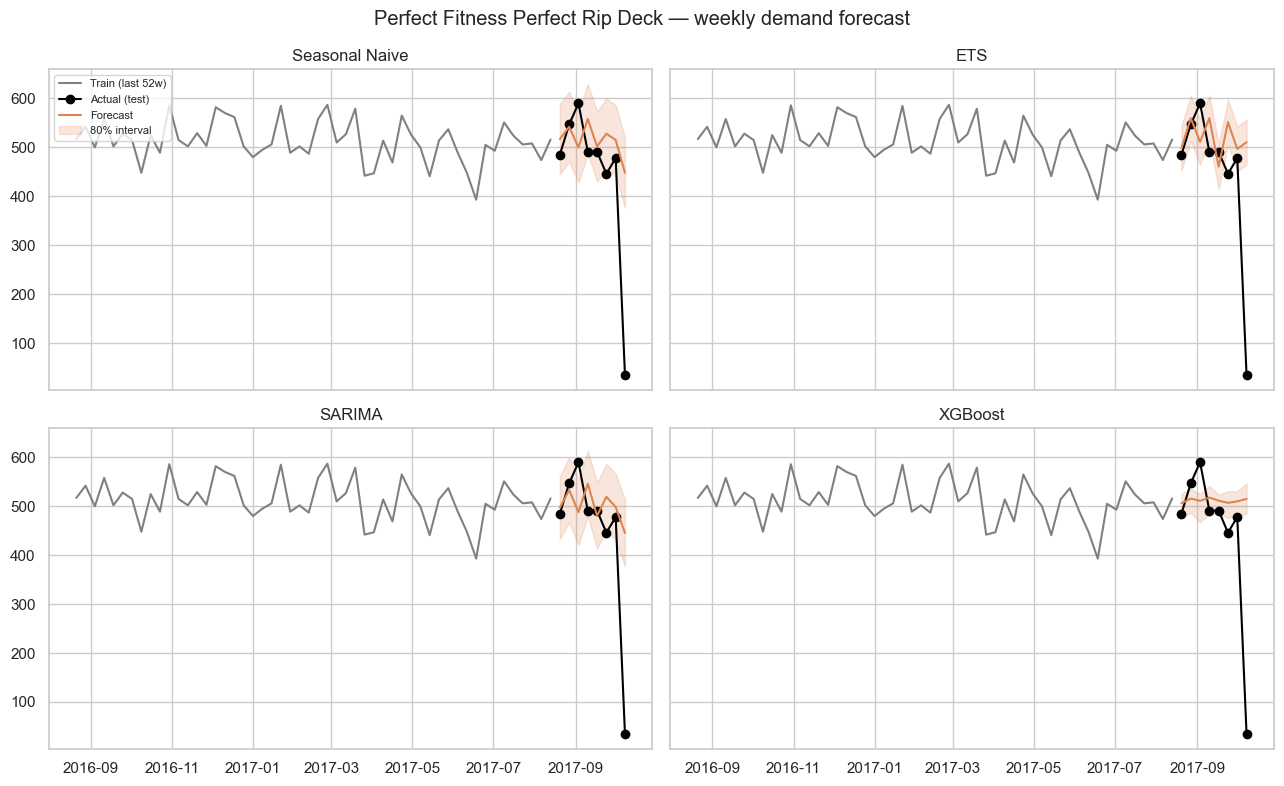

In [4]:
example_id = products.iloc[0]['product_source_id']
example_name = products.iloc[0]['product_name']
train, test = all_series[example_id]
results = all_results[example_id]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
recent_train = train.iloc[-52:]
for ax, (name, result) in zip(axes.flat, results.items(), strict=False):
    ax.plot(recent_train.index, recent_train.values, color='gray', label='Train (last 52w)')
    ax.plot(test.index, test.values, color='black', marker='o', label='Actual (test)')
    ax.plot(result.point_forecast.index, result.point_forecast.values, color='C1', label='Forecast')
    ax.fill_between(
        result.point_forecast.index, result.lower, result.upper,
        color='C1', alpha=0.2, label='80% interval',
    )
    ax.set_title(name)
fig.suptitle(f'{example_name} — weekly demand forecast')
axes[0, 0].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 4. The comparison table

One row per model, averaged across all `N_PRODUCTS` products — this is the table that must exist, complete, before any model gets called "best". `MAPE` is reported alongside `WAPE` since MAPE is unstable when actual demand is near zero (docs/kpi_dictionary.md §5); `interval_coverage` is how often the actual value actually fell inside each model's stated 80% interval — reported, not assumed to be exactly 0.8.

In [5]:
summary_table = (
    detailed_table.drop(columns=['product_name', 'season_length'])
    .groupby('model')
    .mean()
    .sort_values('WAPE')
)
summary_table

,MAE,RMSE,MAPE,WAPE,interval_coverage,avg_interval_width
model,,,,,,
XGBoost,53.77,96.19,279.34,22.41,0.47,43.20
Seasonal Naive,55.20,89.76,252.18,22.65,0.77,102.63
ETS,55.70,95.48,267.02,22.81,0.58,59.99
SARIMA,55.89,92.09,266.30,23.54,0.64,92.52


## 5. Reading the table (only now, after it's complete)

A few things worth naming explicitly rather than skating past:

- Whichever model has the lowest `WAPE` above is the best performer **on this test window, for these products** — not a universal claim.
- If `interval_coverage` is well below 0.8 for a model, that model's intervals are overconfident (too narrow) for this data, whatever its point-forecast accuracy looks like — a model can win on WAPE and still have poorly calibrated intervals.
- SARIMA/ETS may log convergence warnings on some products (~135 training weeks is only ~2.6 annual cycles) — this is disclosed, expected behavior at this data volume (docs/business_requirements.md §7), not a silent failure; their rows in the table above still reflect whatever they actually produced.